In [1]:
import sys
sys.path.append('..')

import numpy as np
import hmm
import emission_model
import matplotlib.pyplot as plt

import numpy as np
import hmm
import emission_model
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../../datasets/btcusd_1-min_data.csv')

In [3]:
df['Timestamp'][0]

np.float64(1325412060.0)

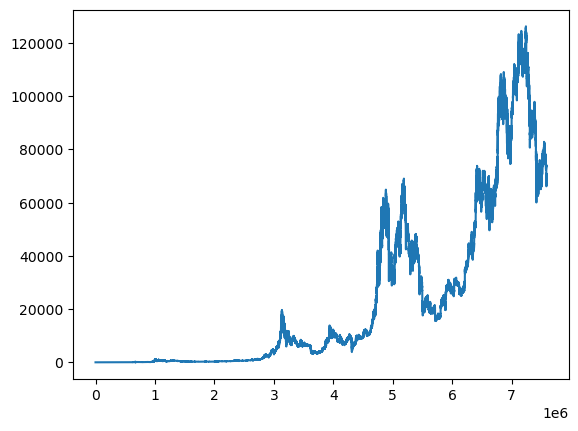

In [4]:
plt.plot(df['Close'])

In [5]:
df["Date"] = pd.to_datetime(df['Timestamp'], unit='s', utc=True)
df = df.set_index('Date')

daily_close = df['Close'].resample('D').last()

In [6]:
L = np.array(daily_close).shape[0]
init_train = 2*L // 3
final_train = int((L)) - 2

init_test = int((2 * L) // 3) 
final_test = L-1

returns = np.log(daily_close.shift(-1) /  daily_close )
data_obs = np.array(returns).reshape(1, -1)[:, init_train:final_train+1]

In [7]:
daily_close.isna().any().any()

np.False_

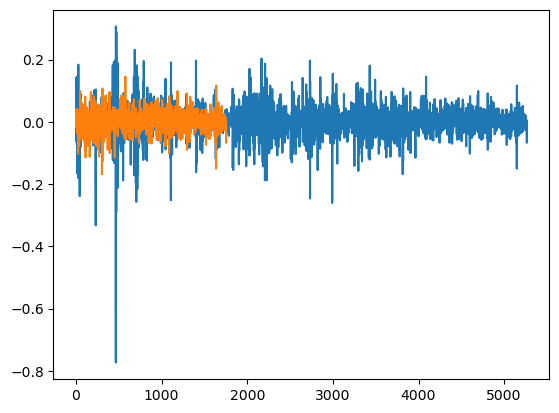

In [8]:
plt.plot(np.array(returns))
plt.plot(data_obs[0, :])

In [9]:
data_obs.shape

(1, 1755)

In [10]:
from tqdm import tqdm
### Student's emission
err = []
HMM_list = []
N_cycles = 5

for i in tqdm(range(N_cycles)):
    
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    
    params = np.array([
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05), np.random.uniform(3.1, 40)],  # state 0
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05), np.random.uniform(3.1, 40)],  # state 1
    #[np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05), np.random.uniform(3.1, 40)]  # state 2
    ])
    
    emission = emission_model.Student_Emission(2, data_obs, params)
    HMM = hmm.Hmm(2, emission, pi, A=None)
    
    err.append(HMM.Baum_Welch(data_obs, N_max=35, eps=1e-5))
    HMM_list.append(HMM)

  0%|          | 0/5 [00:00<?, ?it/s]

############################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration #1------------ -logL = [-1.87250992]------------ $|\Delta$| = 100%
Iteration #2------------ -logL = [-2.26203587]------------ $|\Delta$| = 100%
Iteration #3------------ -logL = [-2.26282462]------------ $|\Delta$| = [0.03486889]%
Iteration #4------------ -logL = [-2.21465808]------------ $|\Delta$| = [2.12860231]%
Iteration #5------------ -logL = [-2.25320585]------------ $|\Delta$| = [1.74057423]%
Iteration #6------------ -logL = [-2.26653297]------------ $|\Delta$| = [0.59147365]%
Iteration #7------------ -logL = [-2.26922467]------------ $|\Delta$| = [0.11875863]%
Iteration #8------------ -logL = [-2.27068582]------------ $|\Delta$| = [0.06438976]%
Iteration #9------------ -logL = [-2.26928115]------------ $|\Delta$| = [0.06186105]%
Iteration #10------------ -logL = [-2.24400167]------------ $|\Delta$|

 20%|██        | 1/5 [00:01<00:07,  1.79s/it]

Iteration #33------------ -logL = [-2.27014085]------------ $|\Delta$| = [0.02745018]%
Iteration #34------------ -logL = [-2.26851125]------------ $|\Delta$| = [0.07178383]%
Iteration #35------------ -logL = [-2.27057125]------------ $|\Delta$| = [0.09080824]%
Iteration #36------------ -logL = [-2.26975463]------------ $|\Delta$| = [0.03596518]%
Learning Finished
###############################################################################################################
############################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration #1------------ -logL = [-2.02056843]------------ $|\Delta$| = 100%
Iteration #2------------ -logL = [-2.26817898]------------ $|\Delta$| = 100%
Iteration #3------------ -logL = [-2.27665188]------------ $|\Delta$| = [0.37355535]%
Iteration #4------------ -logL = [-2.28147956]------------ $|\Delta$| = [0.2120518]%
Iteration #5-----------

 40%|████      | 2/5 [00:02<00:03,  1.23s/it]

...

Iteration #36------------ -logL = [-2.26850413]------------ $|\Delta$| = [0.02207733]%
Learning Finished
###############################################################################################################
############################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration #1------------ -logL = [-1.62907025]------------ $|\Delta$| = 100%
Iteration #2------------ -logL = [-2.216271]------------ $|\Delta$| = 100%
Iteration #3------------ -logL = [-2.26165385]------------ $|\Delta$| = [2.04771216]%
Iteration #4------------ -logL = [-2.26194123]------------ $|\Delta$| = [0.01270664]%
Iteration #5------------ -logL = [-2.25093052]------------ $|\Delta$| = [0.4867815]%
Iteration #6------------ -logL = [-1.9627527]------------ $|\Delta$| = [12.80260843]%
Iteration #7------------ -logL = [-2.26183845]------------ $|\Delta$| = [15.2380762]%
Iteration #8------------ -lo

 80%|████████  | 4/5 [00:05<00:01,  1.50s/it]

Iteration #32------------ -logL = [-2.28022778]------------ $|\Delta$| = [0.01999232]%
Iteration #33------------ -logL = [-2.28065684]------------ $|\Delta$| = [0.01881646]%
Iteration #34------------ -logL = [-2.28105862]------------ $|\Delta$| = [0.017617]%
Iteration #35------------ -logL = [-2.28143313]------------ $|\Delta$| = [0.01641837]%
Iteration #36------------ -logL = [-2.28178099]------------ $|\Delta$| = [0.01524728]%
Learning Finished
###############################################################################################################
############################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration #1------------ -logL = [-1.88182349]------------ $|\Delta$| = 100%
Iteration #2------------ -logL = [-2.26060769]------------ $|\Delta$| = 100%
Iteration #3------------ -logL = [-2.26402575]------------ $|\Delta$| = [0.15120101]%
Iteration #4-----------

100%|██████████| 5/5 [00:07<00:00,  1.53s/it]

Iteration #35------------ -logL = [-2.26533826]------------ $|\Delta$| = [0.25112878]%
Iteration #36------------ -logL = [-2.2696318]------------ $|\Delta$| = [0.18953205]%
Learning Finished
###############################################################################################################


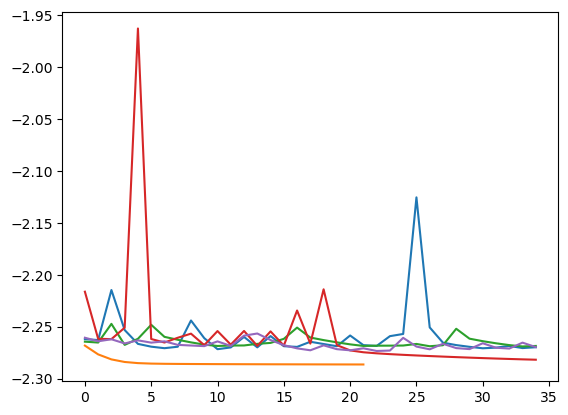

In [13]:
import matplotlib.pyplot as plt

for i in range(N_cycles):
    
    plt.plot(err[i][1:])

In [12]:
print(HMM_list[-1].emission.gauss_params)

AttributeError: 'Student_Emission' object has no attribute 'gauss_params'

In [ ]:
HMM=HMM_list[0]
HMM.Viterbi(data_obs)

In [ ]:
print(HMM.best_seqs.shape)

(1, 1755)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_regimes(dates,prices, hidden_states, n_states):
    
    
    colors = ['grey', 'red', 'green'][::-1]
    
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    ax.plot(dates, prices, color='black', linewidth=2, zorder=2)
    
    # colora le regioni
    i = 0
    while i < len(hidden_states):
        state = int(hidden_states[i])
        j = i
        # trova fino a dove dura questo regime
        while j < len(hidden_states) and hidden_states[j] == state:
            j += 1
        ax.axvspan(dates[i], dates[min(j, len(dates)-1)], 
                   alpha=0.3, color=colors[state], zorder=1)
        i = j
    
    # legenda manuale
    from matplotlib.patches import Patch
    legend = [Patch(facecolor=colors[k], alpha=0.3, label=f'Regime {k}') 
              for k in range(n_states)]
    ax.legend(handles=legend, loc='upper left')
    
    ax.set_xlabel('time')
    ax.set_ylabel('return')
    plt.tight_layout()
    plt.show()

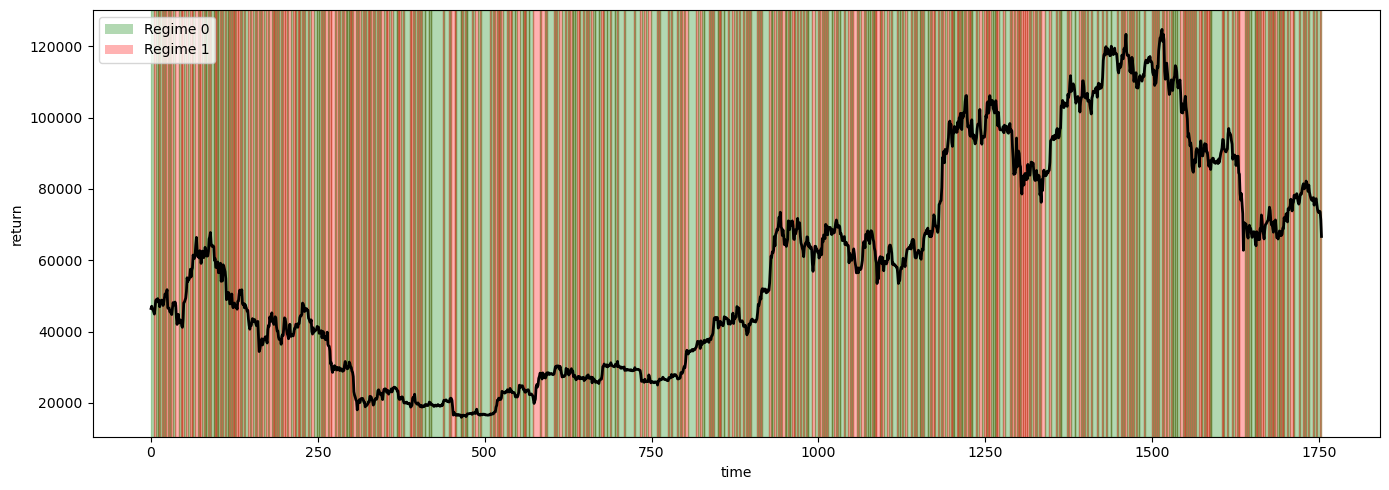

In [ ]:
dates = [i for i in range(final_train - init_train +1)]

plot_regimes(dates[:], np.array(daily_close)[init_train:final_train+1], HMM.best_seqs[0, :] , n_states=2)

In [ ]:
data_obs_test=np.array(returns).reshape(1, -1)[:, init_test:final_test]
HMM.Viterbi(data_obs_test)

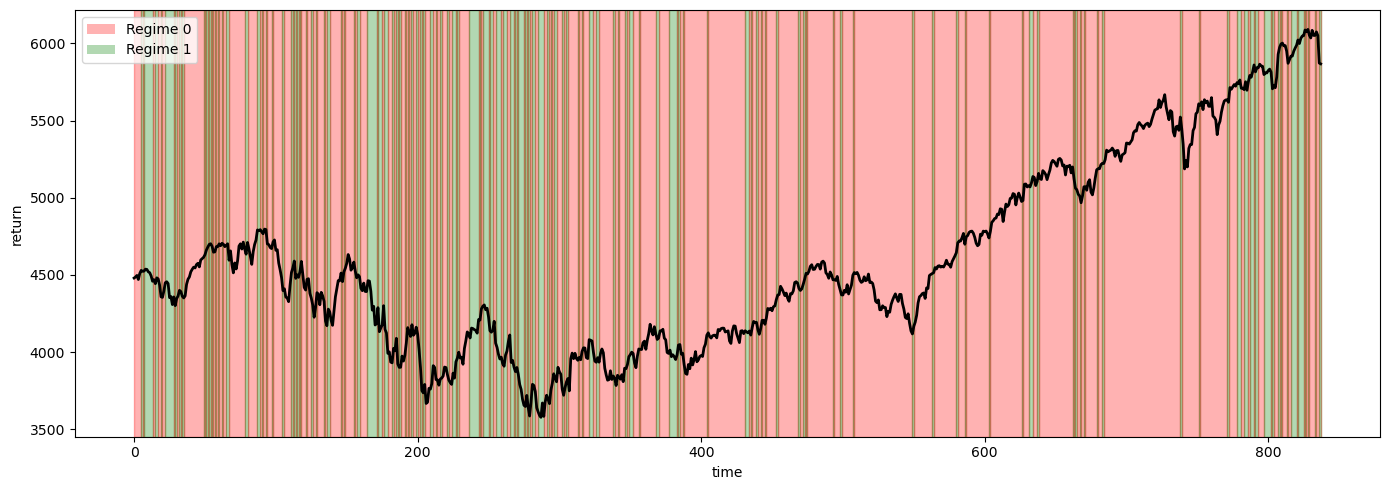

In [ ]:
dates = [i for i in range(final_test-init_test)]

plot_regimes(dates[:], np.array(df['S&P500'])[init_test:final_test], HMM.best_seqs[0, :] , n_states=2)

In [ ]:
test_likelihood = HMM.compute_likelihood(data_obs_test)

In [ ]:
test_likelihood

array([3.5076636])

In [ ]:
### Student's emission
err = []
HMM_list = []
for i in range(15):
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    #emission = emission_model.Discrete_Emission(2, data_obs, 2, B=None)
    student_params = np.array([
    [np.random.uniform(-0.05, 0.05), np.random.uniform(-0.01, 0.01), 6],  # state 0
    [np.random.uniform(-0.05, 0.05), np.random.uniform(-0.01, 0.01), 6],  # state 1
])
    emission = emission_model.Student_Emission(2, data_obs, student_params=student_params)
    HMM = hmm.Hmm(2, 2, emission, pi, A=None)
    err.append(HMM.Baum_Welch_algorithm(data_obs, N_max=35, eps=1e-8))
    HMM_list.append(HMM)
err = np.array(err)

ValueError: f(a) and f(b) must have different signs